# Notebook 05: Feed-Forward Network and Layer Normalization

The two remaining components of a transformer block:
- **Feed-Forward Network (FFN)**: Two linear layers with ReLU activation
- **Layer Normalization**: Normalizes activations for stable training
- **Residual Connections**: Skip connections around each sub-layer

A transformer block is:
```
x = x + MultiHeadAttention(LayerNorm(x))
x = x + FFN(LayerNorm(x))
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Layer Normalization

Layer norm normalizes across the feature dimension (last axis):

$$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$$
$$y_i = \gamma \hat{x}_i + \beta$$

Where $\mu$ and $\sigma^2$ are the mean and variance across features, and $\gamma$, $\beta$ are learnable parameters.

In [2]:
class LayerNorm:
    """Layer normalization with learnable parameters."""
    
    def __init__(self, d_model, eps=1e-5):
        self.gamma = np.ones(d_model)   # scale
        self.beta = np.zeros(d_model)   # shift
        self.eps = eps
        
        # Gradients
        self.dgamma = None
        self.dbeta = None
        
        # Cache
        self.x_hat = None
        self.std_inv = None
        self.x = None
    
    def forward(self, x):
        """Forward pass.
        
        Args:
            x: input of shape (..., d_model)
        Returns:
            normalized output of same shape
        """
        self.x = x
        mean = np.mean(x, axis=-1, keepdims=True)
        var = np.var(x, axis=-1, keepdims=True)
        self.std_inv = 1.0 / np.sqrt(var + self.eps)
        self.x_hat = (x - mean) * self.std_inv
        return self.gamma * self.x_hat + self.beta
    
    def backward(self, dout):
        """Backward pass.
        
        Args:
            dout: gradient of shape (..., d_model)
        Returns:
            dx: gradient w.r.t. input
        """
        # Flatten all dims except last for gradient accumulation
        orig_shape = dout.shape
        D = orig_shape[-1]
        dout_flat = dout.reshape(-1, D)
        x_hat_flat = self.x_hat.reshape(-1, D)
        
        self.dgamma = np.sum(dout_flat * x_hat_flat, axis=0)
        self.dbeta = np.sum(dout_flat, axis=0)
        
        # Gradient through normalization
        dx_hat = dout * self.gamma  # (..., D)
        N = D  # number of features
        
        # dx = (1/sqrt(var+eps)) * (dx_hat - mean(dx_hat) - x_hat * mean(dx_hat * x_hat))
        dx = self.std_inv * (
            dx_hat 
            - np.mean(dx_hat, axis=-1, keepdims=True) 
            - self.x_hat * np.mean(dx_hat * self.x_hat, axis=-1, keepdims=True)
        )
        return dx

# Test
d_model = 64
ln = LayerNorm(d_model)
x = np.random.randn(2, 8, d_model) * 5 + 3  # mean ~3, std ~5
y = ln.forward(x)

print(f"Before LayerNorm: mean={x.mean(axis=-1).mean():.2f}, std={x.std(axis=-1).mean():.2f}")
print(f"After LayerNorm:  mean={y.mean(axis=-1).mean():.6f}, std={y.std(axis=-1).mean():.4f}")
print(f"Shape preserved: {x.shape} -> {y.shape}")

Before LayerNorm: mean=3.15, std=4.84
After LayerNorm:  mean=-0.000000, std=1.0000
Shape preserved: (2, 8, 64) -> (2, 8, 64)


## 2. Feed-Forward Network

$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

Typically the inner dimension $d_{ff}$ is 4x the model dimension. We use $d_{ff} = 256$ with $d_{model} = 64$.

In [3]:
class FeedForward:
    """Two-layer feed-forward network with ReLU."""
    
    def __init__(self, d_model, d_ff):
        scale1 = np.sqrt(2.0 / (d_model + d_ff))
        scale2 = np.sqrt(2.0 / (d_ff + d_model))
        
        self.W1 = np.random.randn(d_model, d_ff) * scale1
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_ff, d_model) * scale2
        self.b2 = np.zeros(d_model)
        
        # Gradients
        self.dW1 = None
        self.db1 = None
        self.dW2 = None
        self.db2 = None
        
        # Cache
        self.x = None
        self.hidden = None
        self.relu_mask = None
    
    def forward(self, x):
        """Forward pass: x -> Linear -> ReLU -> Linear.
        
        Args:
            x: input of shape (..., d_model)
        Returns:
            output of shape (..., d_model)
        """
        self.x = x
        
        # First linear layer
        self.hidden = x @ self.W1 + self.b1  # (..., d_ff)
        
        # ReLU
        self.relu_mask = (self.hidden > 0).astype(float)
        self.hidden_relu = self.hidden * self.relu_mask
        
        # Second linear layer
        output = self.hidden_relu @ self.W2 + self.b2  # (..., d_model)
        return output
    
    def backward(self, dout):
        """Backward pass.
        
        Args:
            dout: gradient of shape (..., d_model)
        Returns:
            dx: gradient w.r.t. input
        """
        # Gradient through second linear layer
        d_model = dout.shape[-1]
        d_ff = self.W1.shape[1]
        
        self.dW2 = self.hidden_relu.reshape(-1, d_ff).T @ dout.reshape(-1, d_model)
        self.db2 = dout.reshape(-1, d_model).sum(axis=0)
        d_hidden_relu = dout @ self.W2.T
        
        # Gradient through ReLU
        d_hidden = d_hidden_relu * self.relu_mask
        
        # Gradient through first linear layer
        self.dW1 = self.x.reshape(-1, d_model).T @ d_hidden.reshape(-1, d_ff)
        self.db1 = d_hidden.reshape(-1, d_ff).sum(axis=0)
        dx = d_hidden @ self.W1.T
        
        return dx

# Test
d_model = 64
d_ff = 256
ffn = FeedForward(d_model, d_ff)

x = np.random.randn(2, 8, d_model)
y = ffn.forward(x)
print(f"FFN input:  {x.shape}")
print(f"FFN output: {y.shape}")

dout = np.random.randn(2, 8, d_model)
dx = ffn.backward(dout)
print(f"FFN dx:     {dx.shape}")
print(f"\nW1: {ffn.W1.shape}, W2: {ffn.W2.shape}")
print(f"Total FFN params: {ffn.W1.size + ffn.b1.size + ffn.W2.size + ffn.b2.size:,}")

FFN input:  (2, 8, 64)
FFN output: (2, 8, 64)
FFN dx:     (2, 8, 64)

W1: (64, 256), W2: (256, 64)
Total FFN params: 33,088


## 3. Residual Connection

Residual connections (skip connections) help gradient flow through deep networks:
$$\text{output} = x + \text{SubLayer}(\text{LayerNorm}(x))$$

The gradient flows directly through the addition, preventing vanishing gradients.

In [4]:
# Demonstrate residual connection
x = np.random.randn(2, 8, d_model)
ln = LayerNorm(d_model)
ffn = FeedForward(d_model, d_ff)

# Pre-norm residual block
x_norm = ln.forward(x)
ffn_out = ffn.forward(x_norm)
output = x + ffn_out  # residual connection

print(f"Input:    {x.shape}")
print(f"Output:   {output.shape}")
print(f"\nResidual allows gradient to flow directly through x.")

# Backward through residual block
dout = np.random.randn(2, 8, d_model)

# dout flows through both paths:
# Path 1: directly to dx (residual)
# Path 2: through FFN -> LayerNorm
d_ffn_out = dout  # gradient through addition
d_x_norm = ffn.backward(d_ffn_out)
d_x_ln = ln.backward(d_x_norm)
dx = dout + d_x_ln  # sum of residual path + sublayer path

print(f"\nGradient flows through residual (dout) + sublayer (d_x_ln)")
print(f"dx shape: {dx.shape}")

Input:    (2, 8, 64)
Output:   (2, 8, 64)

Residual allows gradient to flow directly through x.

Gradient flows through residual (dout) + sublayer (d_x_ln)
dx shape: (2, 8, 64)


## 4. Gradient Checking

In [5]:
def numerical_gradient(f, x, eps=1e-5):
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        old_val = x[idx]
        x[idx] = old_val + eps
        fp = f(x)
        x[idx] = old_val - eps
        fm = f(x)
        grad[idx] = (fp - fm) / (2 * eps)
        x[idx] = old_val
        it.iternext()
    return grad

def relative_error(a, b):
    return np.max(np.abs(a - b) / (np.maximum(np.abs(a) + np.abs(b), 1e-8)))

# --- LayerNorm gradient check ---
print("=== LayerNorm Gradient Check ===")
np.random.seed(42)
D = 8
ln = LayerNorm(D)
x = np.random.randn(2, 4, D)
dout = np.random.randn(2, 4, D)

y = ln.forward(x)
dx = ln.backward(dout)

def loss_ln_x(x_in):
    return np.sum(ln.forward(x_in) * dout)

num_grad = numerical_gradient(loss_ln_x, x.copy())
err = relative_error(dx, num_grad)
print(f"x gradient error:     {err:.2e} {'PASS' if err < 1e-5 else 'FAIL'}")

def loss_ln_gamma(gamma):
    ln.gamma = gamma
    return np.sum(ln.forward(x) * dout)

num_grad = numerical_gradient(loss_ln_gamma, ln.gamma.copy())
err = relative_error(ln.dgamma, num_grad)
print(f"gamma gradient error: {err:.2e} {'PASS' if err < 1e-5 else 'FAIL'}")

# --- FFN gradient check ---
print("\n=== FFN Gradient Check ===")
np.random.seed(42)
D, D_FF = 8, 16
ffn = FeedForward(D, D_FF)
x = np.random.randn(2, 4, D)
dout = np.random.randn(2, 4, D)

y = ffn.forward(x)
dx = ffn.backward(dout)

for name, W, dW in [
    ('W1', ffn.W1, ffn.dW1),
    ('W2', ffn.W2, ffn.dW2),
]:
    def loss_fn(W_val, name=name):
        setattr(ffn, name, W_val)
        return np.sum(ffn.forward(x) * dout)
    
    num_grad = numerical_gradient(loss_fn, W.copy())
    err = relative_error(dW, num_grad)
    print(f"{name} gradient error: {err:.2e} {'PASS' if err < 1e-5 else 'FAIL'}")

def loss_ffn_x(x_in):
    return np.sum(ffn.forward(x_in) * dout)

num_grad = numerical_gradient(loss_ffn_x, x.copy())
err = relative_error(dx, num_grad)
print(f"x gradient error:  {err:.2e} {'PASS' if err < 1e-5 else 'FAIL'}")

=== LayerNorm Gradient Check ===
x gradient error:     4.13e-08 PASS
gamma gradient error: 1.73e-09 PASS

=== FFN Gradient Check ===
W1 gradient error: 1.97e-09 PASS
W2 gradient error: 5.54e-09 PASS
x gradient error:  1.41e-09 PASS


## 5. Visualizing the Effect of LayerNorm

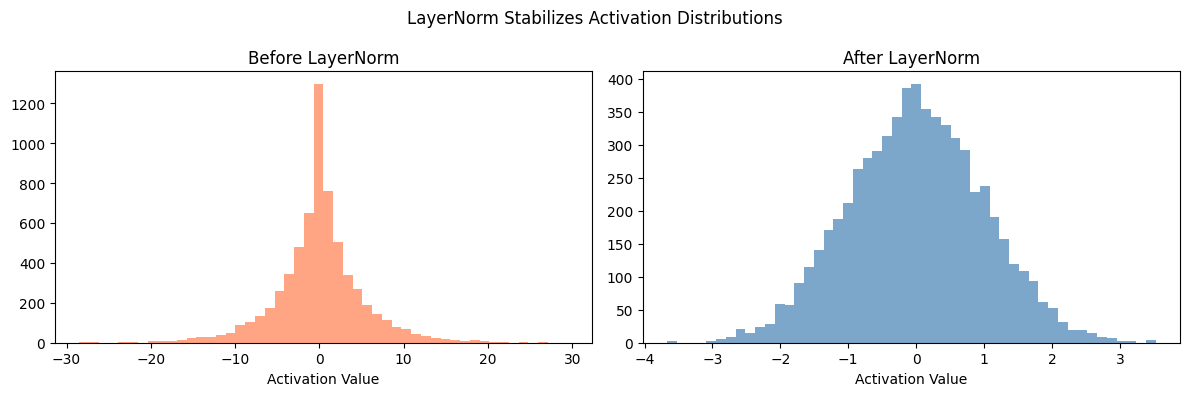

In [6]:
# Show how LayerNorm stabilizes activations
np.random.seed(42)
d_model = 64
ln = LayerNorm(d_model)

# Simulate activations with varying magnitudes
x_varied = np.random.randn(100, d_model) * np.random.uniform(0.1, 10, (100, 1))
x_normed = ln.forward(x_varied)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(x_varied.flatten(), bins=50, alpha=0.7, color='coral')
axes[0].set_title('Before LayerNorm')
axes[0].set_xlabel('Activation Value')

axes[1].hist(x_normed.flatten(), bins=50, alpha=0.7, color='steelblue')
axes[1].set_title('After LayerNorm')
axes[1].set_xlabel('Activation Value')

plt.suptitle('LayerNorm Stabilizes Activation Distributions')
plt.tight_layout()
plt.show()

## Summary

We've built:
- **Layer Normalization** with learnable scale/shift and full backprop
- **Feed-Forward Network** (two linear layers + ReLU) with backprop
- **Residual connections** that combine both
- **Gradient checking** for all components

Next notebook: **Full Transformer Model** - assembling everything into a complete decoder-only transformer.